#1. TypedDict으로 데이터 타입에 맞는 값 만들기

In [1]:
from typing import TypedDict

In [2]:
class User(TypedDict):
    id: int # 사용자 아이디 : 정수
    name: str # 사용자 이름 : 문자열
    email: str # 사용자 이메일 : 문자열

user1 : User = {
    'id': 1,
    'name': 'tom',
    'email': 'test@naver.com'
}
print(user1)

{'id': 1, 'name': 'tom', 'email': 'test@naver.com'}


In [3]:
# 타입과 다른 value 입력 -> TypedDict는 타입힌트라서 실행시 오류는 발생하지 않음
user2 : User = {
    'id': 2,
    'name': 123,
    'email': 'test@naver.com'
}
print(user2)

{'id': 2, 'name': 123, 'email': 'test@naver.com'}


In [4]:
# 2. BaseModel : 1) 타입 지정 2) 강제성이 있음 -> 다른 타입의 값을 입력하면 실행시 오류
from pydantic import BaseModel

class User(BaseModel): # 파이단틱의 BaseModel을 상속받아 정의한 User 클래스
    # 입력된 데이터가 해당 타입에 맞는 자동으로 검증할 수 있음
    id: int # 사용자 아이디 : 정수
    name: str # 사용자 이름 : 문자열
    email: str # 사용자 이메일 : 문자열

user_data: dict = {
    'id': 1,
    'name': 'tom',
    'email': 'test@naver.com'
}
user1 =User(**user_data)
print(user1)

id=1 name='tom' email='test@naver.com'


In [5]:
user_data:  dict = {
    'id': 1,
    'name': '123',
    'email': 'test@naver.com'
}
user2 = User(**user_data)
print(user2)

id=1 name='123' email='test@naver.com'


In [6]:
from typing import TypedDict, Annotated

def add(left:list[str], right:list[str]) -> list[str]: 
    return left + right

class State(TypedDict):
    messages: Annotated[list[str], add]
    # messages는 list[str] 타입이며, 여러 값이 동시에 들어오면 add 함수를 이용해서 합쳐라

In [7]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

msg1 = [HumanMessage(content="hello", id="1")]
msg2 = [AIMessage(content="hi, may i help you", id="2")]

add_messages(msg1, msg2)

[HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='hi, may i help you', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]

In [8]:
msg1 = [HumanMessage(content="hello", id="1")]
msg2 = [AIMessage(content="hi, may i help you", id="1")]

add_messages(msg1, msg2)

[AIMessage(content='hi, may i help you', additional_kwargs={}, response_metadata={}, id='1', tool_calls=[], invalid_tool_calls=[])]

In [9]:
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [10]:
# 그래프 상태 (State)에 답변 결과를 반환하기
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph

# State 선언
class State(TypedDict):
    messsages: Annotated[list[str], add]

# 그래프 객체 생성
graph = StateGraph(State)

# 노드 만들기
def chatbot(state: State):
    question = state['messsages']
    answer = f"사용가 입력을 그대로 반환하는 챗봇입니다. {question} 라는 질문을 받았습니다."
    return { 'messages':[answer]}

graph.add_node('chatbot', chatbot) # 구현한 노드를 추가
# 노드의 이름

In [11]:
from langgraph.graph import START, END

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

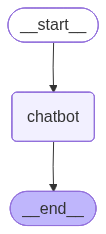

In [12]:
test = graph.compile()
test

In [ ]:
def routing_function(state: State):
    if len(state["messsages"][-1]) > 1000:
        return True
    return False

# 파라미터로 보낸 라우팅 함수(routing_function)의 반환값 (True, False)에 따라
graph.add_conditional_edges(
    "chatbot",
    routing_function,
    {True: "summary", False: END}
)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
